<a href="https://colab.research.google.com/github/muneer-ahmad10/Natural-Language-processing/blob/main/LSTM_Text_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

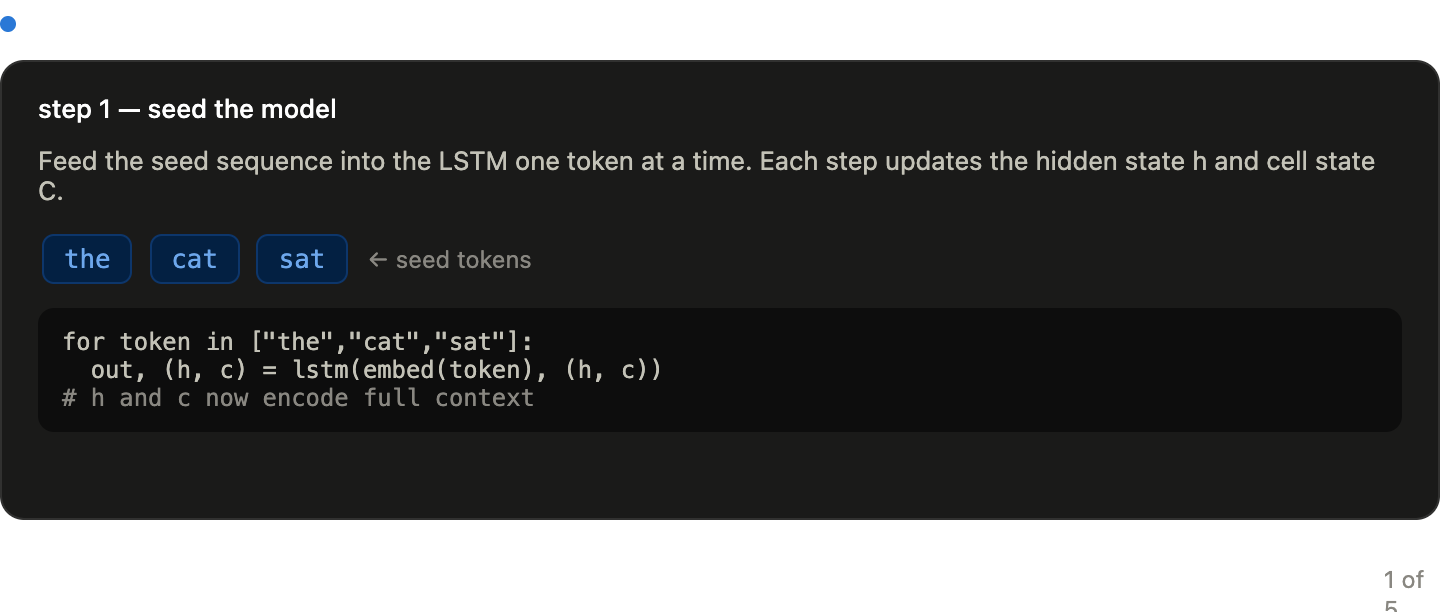

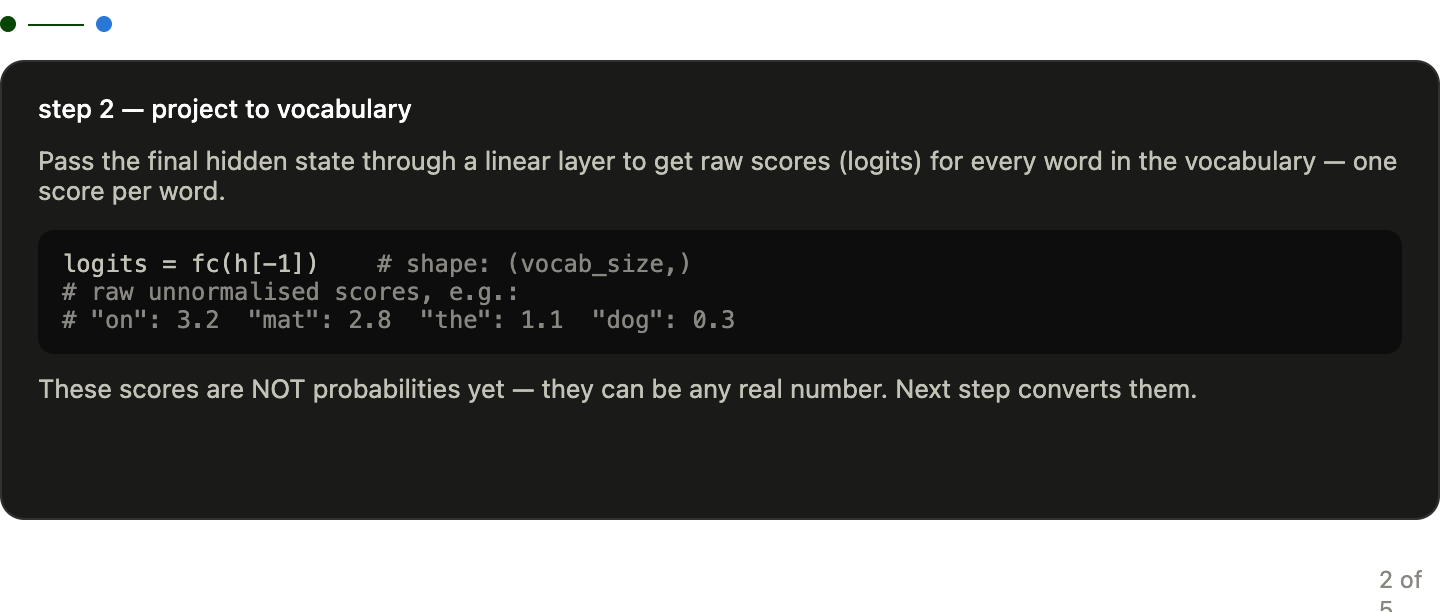

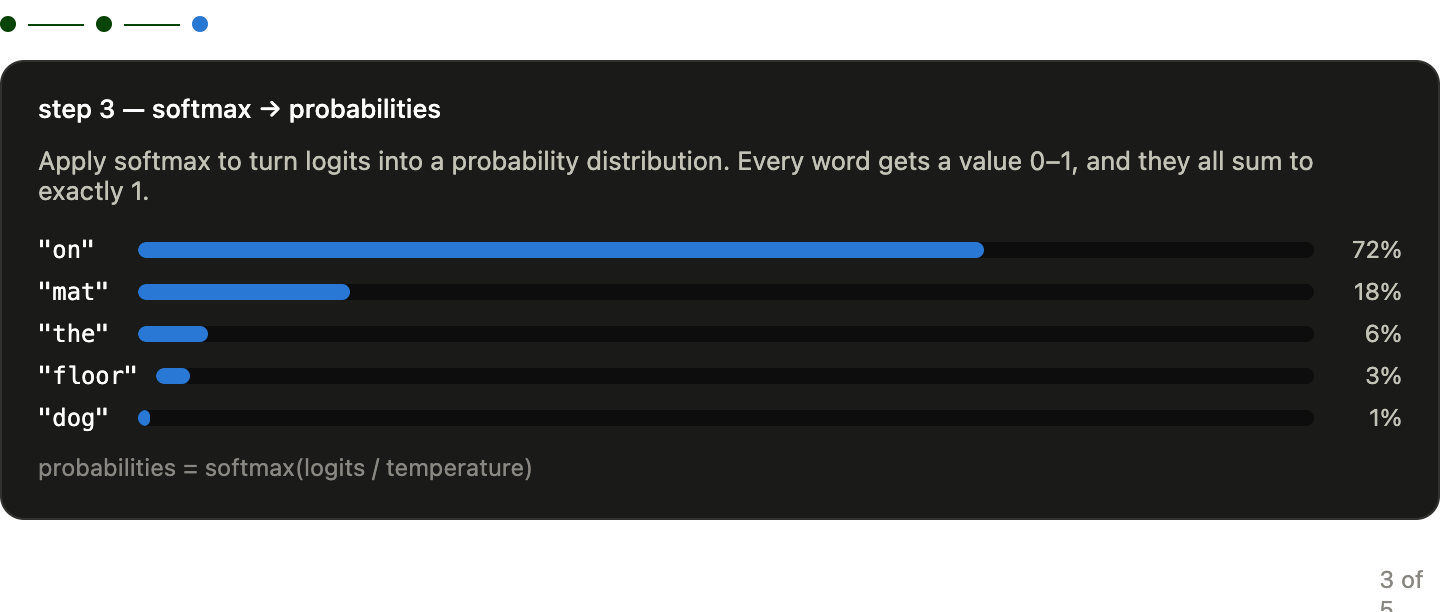

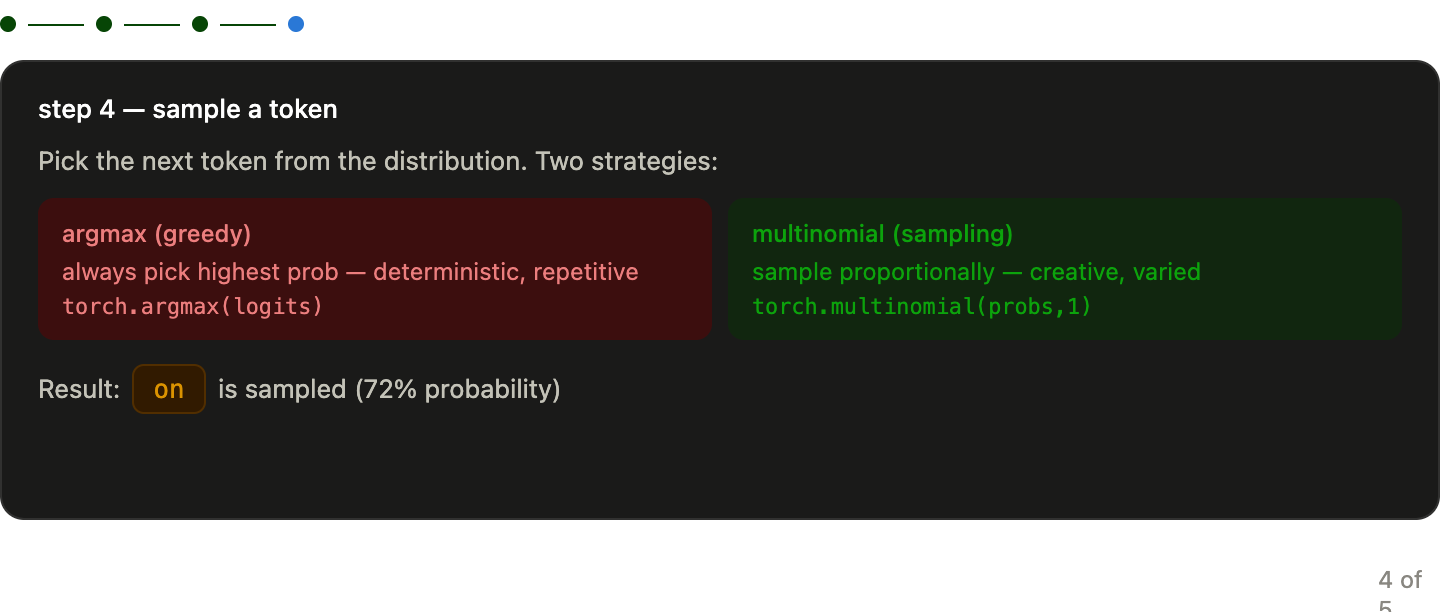

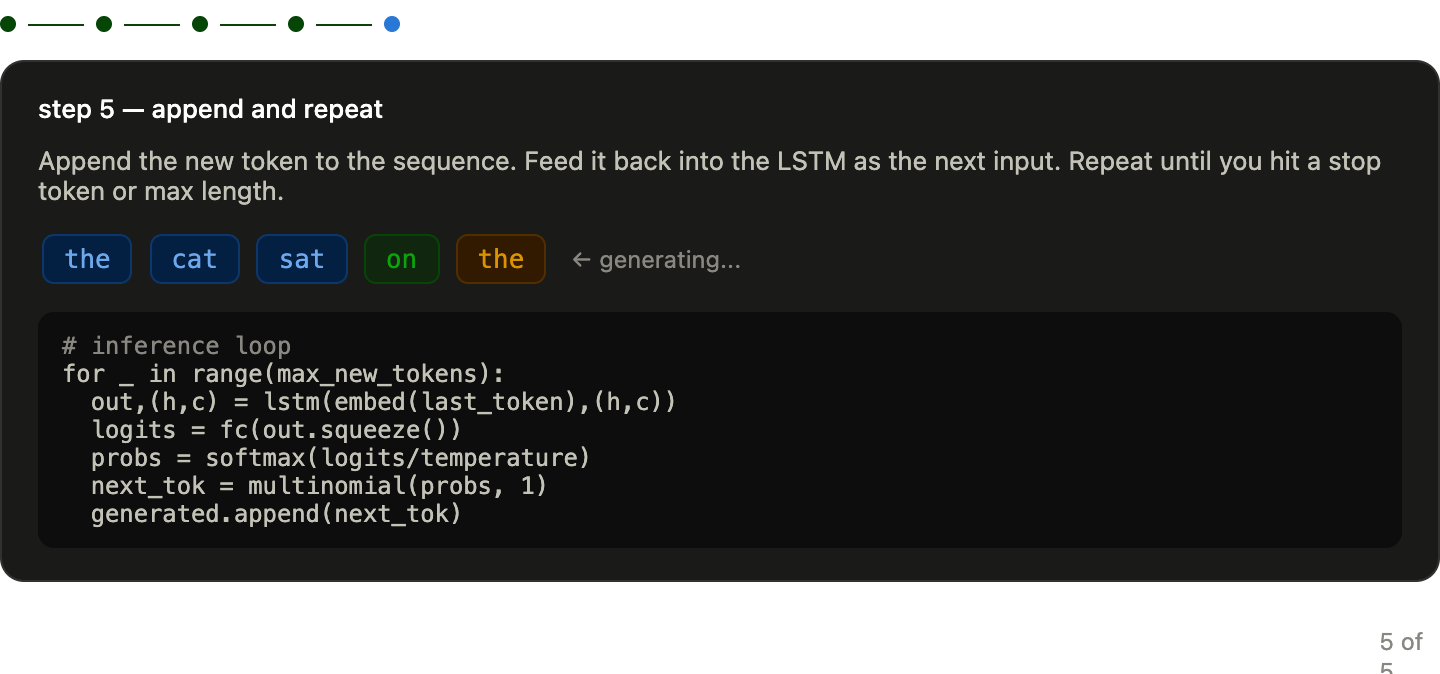

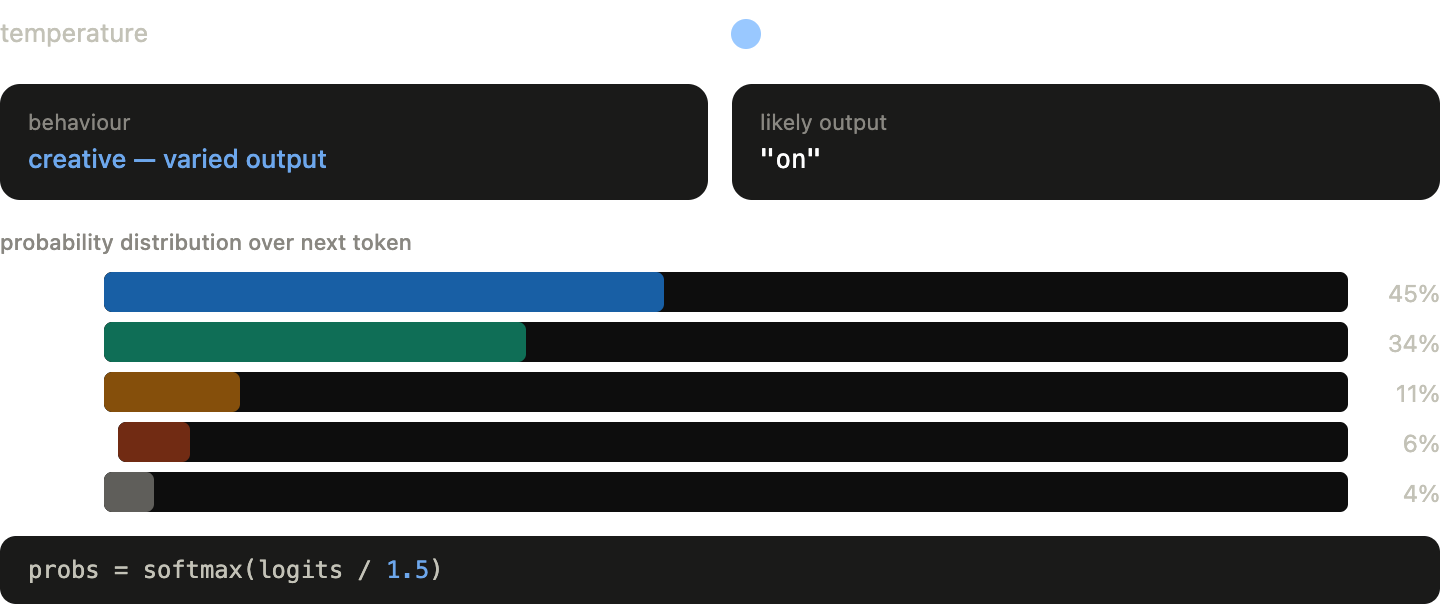

 the model always picks "on" (the top word). Drag to 3.0 — everything flattens and the model picks almost randomly. The sweet spot for creative but coherent text is 0.7–1.0. This is the single most-tested concept in this topic.

# **Key concepts**
An LSTM text generator is trained to predict the next token given all previous tokens. At inference time it uses its own predictions as new inputs — this loop is called autoregressive decoding.
There are two levels: character-level (predicts the next character — great for names and made-up words) and word-level (predicts the next word — more coherent sentences, needs more memory).
Teacher forcing is what makes training different from inference. During training you feed the actual correct previous token as input at every step, even if the model predicted wrong — this makes training stable and fast. During inference there are no correct tokens to feed, so you feed the model's own predictions back in. This training/inference mismatch is a deliberate design choice, not a bug.

In [1]:
import torch
import torch.nn as nn

In [22]:
class lstmTextGenerator(nn.Module):
  def __init__(self,vocab_size,embed_dim=64,hidden_dim=128,num_layers=2):
    super().__init__()

    self.embedding=nn.Embedding(vocab_size,embed_dim)

    self.lstm=nn.LSTM(embed_dim,hidden_dim,batch_first=True,num_layers=num_layers,dropout=0.3)

    self.fc=nn.Linear(hidden_dim, vocab_size)

  def forward(self,x,hidden=None):
    x=self.embedding(x)

    out,hidden=self.lstm(x,hidden)

    logits=self.fc(out)

    return logits,hidden

In [23]:
def generate(model, seed_tokens, vocab_size, max_new=50, temperature=1.0):
  model.eval()

  generated=list(seed_tokens)

  hidden=None

  with torch.no_grad():
    seed=torch.tensor(seed_tokens).unsqueeze(0)
    _,hidden=model(seed)


    for _ in range(max_new):
      last=torch.tensor([[generated[-1]]])
      logits,hidden=model(last,hidden)
      logits = logits.squeeze() / temperature
      probs  = torch.softmax(logits, dim=-1)
      next_token = torch.multinomial(probs, 1).item()

      generated.append(next_token)

  return generated

In [24]:
def greedy_generate(model, seed_tokens, vocab_size, max_new=20):
    return generate(model, seed_tokens, vocab_size=vocab_size, max_new=max_new, temperature=0.0001)

In [25]:
def creative_generate(model, seed_tokens, vocab_size, max_new=50):
    return generate(model, seed_tokens, vocab_size=vocab_size, max_new=max_new, temperature=0.8)

In [26]:
vocab_size = 4
char_to_int = {'h': 0, 'e': 1, 'l': 2, 'o': 3}
int_to_char = {v: k for k, v in char_to_int.items()}

#Instantiate the model with your class
# Using small dimensions just for testing
model = lstmTextGenerator(vocab_size=vocab_size, embed_dim=16, hidden_dim=32, num_layers=1)

# 3. Create a seed phrase (e.g., "he") mapped to integers
seed_text = "he"
seed_tokens = [char_to_int[c] for c in seed_text]

#Generate new tokens using your creative function
print("Testing Creative Generation...")
generated_indices = creative_generate(model, seed_tokens, vocab_size=vocab_size, max_new=10)

#Convert the output integers back to characters
generated_text = "".join([int_to_char[idx] for idx in generated_indices])
print(f"Seed input: '{seed_text}'")
print(f"Generated output text: '{generated_text}'")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Testing Creative Generation...
Seed input: 'he'
Generated output text: 'heehoheehlhh'


**Trap 1 — teacher forcing is used at inference**. No. Teacher forcing feeds correct previous tokens during training only. At inference the model feeds its own generated tokens back in. Confusing these two phases is the top trap in this topic.

**Trap 2 — higher temperature always produces better text**. No. Very high temperature (>2.0) makes the distribution nearly uniform — the model starts picking random words with no coherence. Very low temperature (<0.3) produces repetitive, safe but boring text. The sweet spot is 0.7–1.0.

**Trap 3 — temperature=0 is the same as argmax.** Mathematically, temperature=0 is undefined (division by zero in logits/temperature). In practice you either use torch.argmax(logits) directly, or set temperature to a very small value like 0.0001. Some questions ask "what does temperature=0 do" — the correct answer is it produces greedy (always-highest-probability) decoding, but technically the limit rather than the exact value.

**Trap 4 — word-level and character-level generate the same way.** Same loop, different vocabulary. Character-level vocab is tiny (~100 chars) but produces nonsense words if the sequence gets long. Word-level vocab is large (50k+ words) and more coherent but needs much more memory for the embedding layer.

**Trap 5 — the model sees future tokens during generation.** No. The LSTM is strictly left-to-right — hidden state only carries information from past tokens. This is the same causal structure as GPT. Only BERT sees both directions, and BERT does not generate text

**Trap 6 — multinomial sampling always picks the top word**. No. torch.multinomial(probs, 1) samples proportionally — a 72% probability word gets picked ~72% of the time, not 100%. torch.argmax always picks the top word. These two are the main distractor pair in coding MCQs.